<a href="https://colab.research.google.com/github/VasilievNichita/IA_LABS/blob/main/Lab_2_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
!pip -q install kagglehub scikit-learn pandas numpy matplotlib

In [20]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.decomposition import PCA

In [21]:
path = kagglehub.dataset_download("heptapod/titanic")
path

Using Colab cache for faster access to the 'titanic' dataset.


'/kaggle/input/titanic'

In [22]:
os.listdir(path)

['train_and_test2.csv']

In [23]:
csvs = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
csvs

['/kaggle/input/titanic/train_and_test2.csv']

In [24]:
train_path = csvs[0]
train_path

'/kaggle/input/titanic/train_and_test2.csv'

In [25]:
df = pd.read_csv(train_path)
df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   zero         1309 non-null   int64  
 6   zero.1       1309 non-null   int64  
 7   zero.2       1309 non-null   int64  
 8   zero.3       1309 non-null   int64  
 9   zero.4       1309 non-null   int64  
 10  zero.5       1309 non-null   int64  
 11  zero.6       1309 non-null   int64  
 12  Parch        1309 non-null   int64  
 13  zero.7       1309 non-null   int64  
 14  zero.8       1309 non-null   int64  
 15  zero.9       1309 non-null   int64  
 16  zero.10      1309 non-null   int64  
 17  zero.11      1309 non-null   int64  
 18  zero.12      1309 non-null   int64  
 19  zero.1

In [27]:
target = "2urvived"

# Удаляем Passengerid и все zero колонки (они бесполезны)
zero_cols = [c for c in df.columns if "zero" in c.lower()]
drop_cols = ["Passengerid"] + zero_cols

X = df.drop(columns=[target] + drop_cols)
y = df[target].astype(int)

X.head()

,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked
0,22.0,7.2500,0,1,0,3,2.0
1,38.0,71.2833,1,1,0,1,0.0
2,26.0,7.9250,1,0,0,3,2.0
3,35.0,53.1000,1,1,0,1,2.0
4,35.0,8.0500,0,0,0,3,2.0


In [28]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

num_cols, cat_cols

(['Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass', 'Embarked'], [])

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((981, 7), (328, 7))

In [30]:
def evaluate_model(name, pipeline):
    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)

    print("="*70)
    print("MODEL:", name)
    print("Accuracy:", round(accuracy_score(y_test, pred), 4))
    print("Confusion matrix:\n", confusion_matrix(y_test, pred))
    print("Report:\n", classification_report(y_test, pred, digits=4))

In [32]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols)
    ]
)

In [33]:
nb_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", GaussianNB())
])

svm_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", SVC(kernel="rbf", C=2.0, gamma="scale", random_state=42))
])

tree_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(max_depth=5, random_state=42))
])

ada_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", AdaBoostClassifier(n_estimators=300, learning_rate=0.5, random_state=42))
])

In [34]:
evaluate_model("Bayes: GaussianNB", nb_pipeline)
evaluate_model("Functional: SVM (RBF)", svm_pipeline)
evaluate_model("Trees: DecisionTree (depth=5)", tree_pipeline)
evaluate_model("Meta: AdaBoost", ada_pipeline)

MODEL: Bayes: GaussianNB
Accuracy: 0.7348
Confusion matrix:
 [[202  40]
 [ 47  39]]
Report:
               precision    recall  f1-score   support

           0     0.8112    0.8347    0.8228       242
           1     0.4937    0.4535    0.4727        86

    accuracy                         0.7348       328
   macro avg     0.6525    0.6441    0.6478       328
weighted avg     0.7280    0.7348    0.7310       328

MODEL: Functional: SVM (RBF)
Accuracy: 0.7591
Confusion matrix:
 [[214  28]
 [ 51  35]]
Report:
               precision    recall  f1-score   support

           0     0.8075    0.8843    0.8442       242
           1     0.5556    0.4070    0.4698        86

    accuracy                         0.7591       328
   macro avg     0.6816    0.6456    0.6570       328
weighted avg     0.7415    0.7591    0.7460       328

MODEL: Trees: DecisionTree (depth=5)
Accuracy: 0.7622
Confusion matrix:
 [[213  29]
 [ 49  37]]
Report:
               precision    recall  f1-score   suppo

In [35]:
preprocess.fit(X_train)

Xtr = preprocess.transform(X_train)
Xte = preprocess.transform(X_test)

pca = PCA(n_components=2, random_state=42)

Xtr_2d = pca.fit_transform(Xtr)
Xte_2d = pca.transform(Xte)

Xtr_2d.shape, Xte_2d.shape

((981, 2), (328, 2))

In [36]:
def plot_regions(X2d, y, clf, title):
    x_min, x_max = X2d[:, 0].min() - 1, X2d[:, 0].max() + 1
    y_min, y_max = X2d[:, 1].min() - 1, X2d[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = clf.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X2d[:, 0], X2d[:, 1], c=y, s=20, edgecolor="k")
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

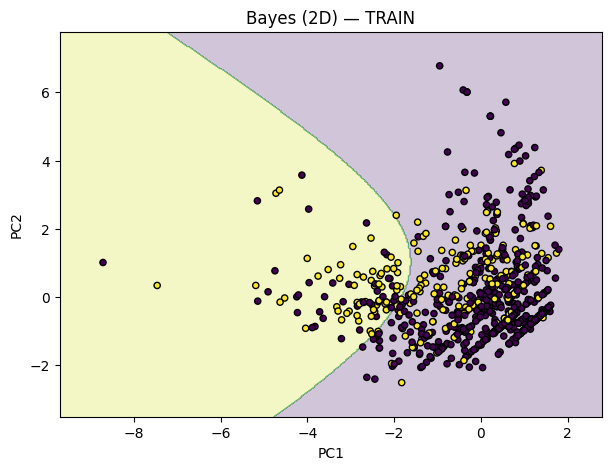

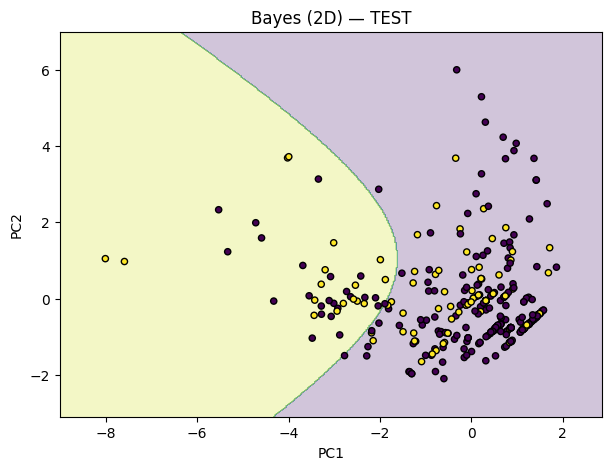

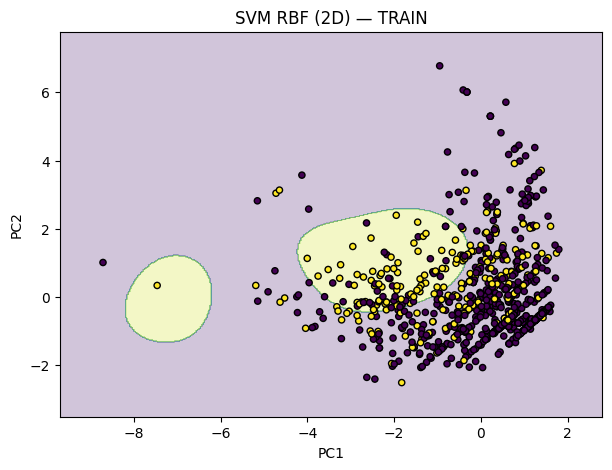

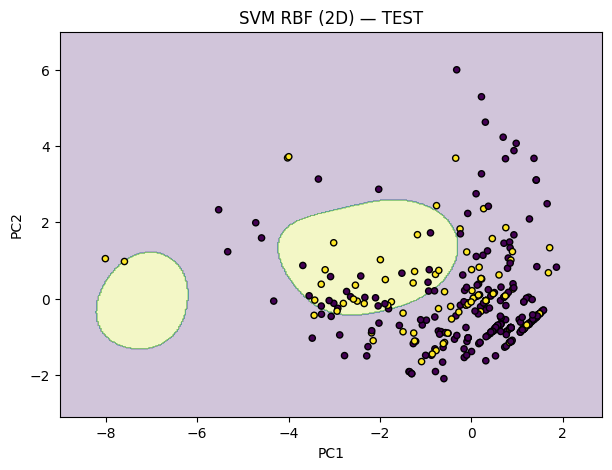

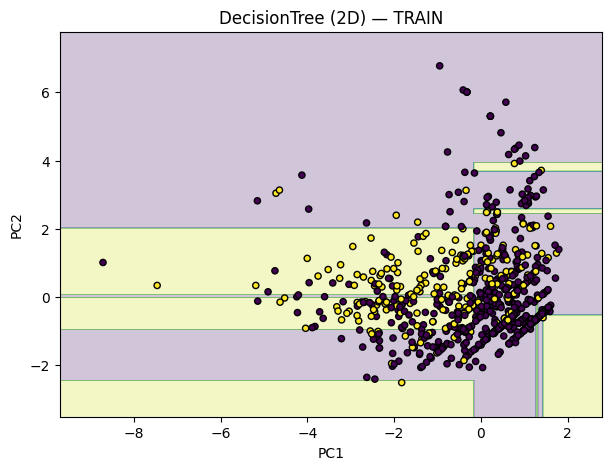

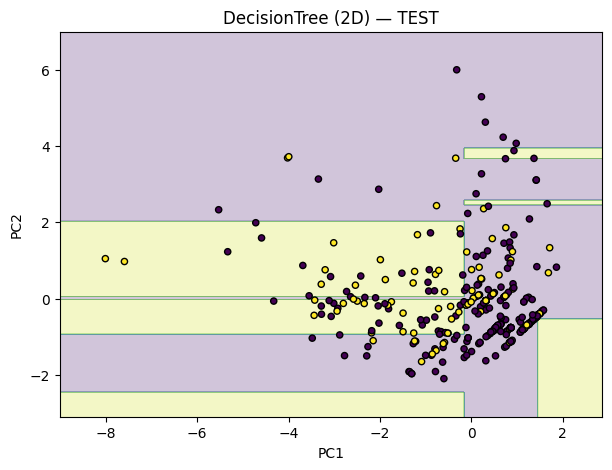

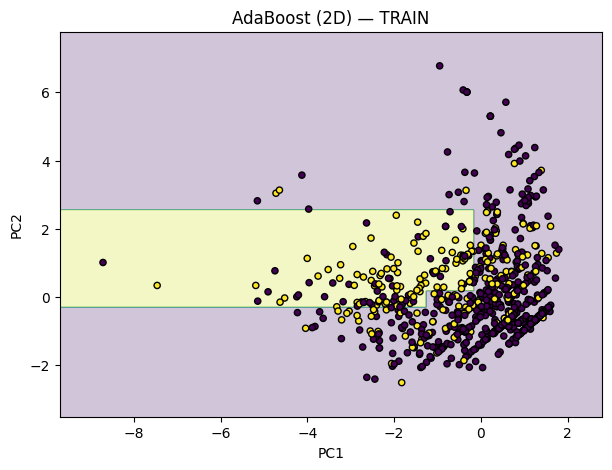

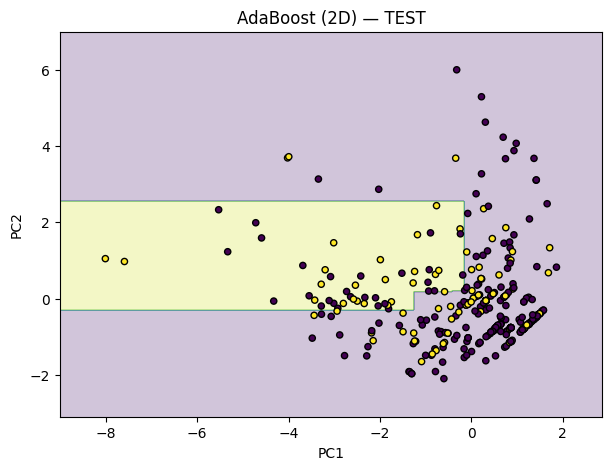

In [37]:
models_2d = {
    "Bayes (2D)": GaussianNB(),
    "SVM RBF (2D)": SVC(kernel="rbf", C=2.0, gamma="scale", random_state=42),
    "DecisionTree (2D)": DecisionTreeClassifier(max_depth=5, random_state=42),
    "AdaBoost (2D)": AdaBoostClassifier(n_estimators=300, learning_rate=0.5, random_state=42),
}

for name, clf in models_2d.items():
    clf.fit(Xtr_2d, y_train)
    plot_regions(Xtr_2d, y_train, clf, f"{name} — TRAIN")
    plot_regions(Xte_2d, y_test, clf, f"{name} — TEST")